In [1]:
import os
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json

from collections import Counter, defaultdict

from sklearn.neighbors import BallTree
from math import radians, sin, cos, sqrt, atan2

In [2]:
spark = SparkSession.builder \
    .appName("final-applications-gen") \
    .master("local[*]") \
    .getOrCreate()

26/01/10 20:05:44 WARN Utils: Your hostname, Lianas-MacBook-Pro.local resolves to a loopback address: 127.0.0.1; using 192.168.20.123 instead (on interface en0)
26/01/10 20:05:44 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/10 20:05:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


# Task 1

This dataset contains daily raw logs about:
- **sessions**: user activity sessions (many per day)
- **applications**: installed apps snapshot per device (usually 1 per device)
- **hardware**: device specs snapshot per device
- **updateEvents**: events like install/uninstall/update
- **users**: user metadata snapshot

I will build a daily state table `userDevice` and then do aggregations + data quality checks.

In [3]:
path1 = "data/applications-gen_raw"
print("Subfolders:", os.listdir(path1)[:10])

Subfolders: ['hardware', 'sessions', 'users', 'applications', 'updateEvents']


In [4]:
days = sorted([d for d in os.listdir(f"{path1}/sessions") if d.startswith("2025-")])
print("Detected days:", days)

Detected days: ['2025-12-03', '2025-12-04', '2025-12-05', '2025-12-06', '2025-12-07', '2025-12-08', '2025-12-09']


Before building the `userDevice` table, I first load one day of data from each raw dataset to

- confirm the folder structure is correct and Spark can read the parquet partitions
- check row counts (to understand which tables are “snapshot-like” vs “event-like”)
- preview a few rows to understand how datasets connect (keys: `userid`, `deviceid`)
- detect obvious data issues early (ex: negative session duration)

After this step, I will start building the `userDevice` day-0 state.

In [5]:
day = days[0]

sessions = spark.read.parquet(f"{path1}/sessions/{day}")
apps = spark.read.parquet(f"{path1}/applications/{day}")
hw = spark.read.parquet(f"{path1}/hardware/{day}")
updates = spark.read.parquet(f"{path1}/updateEvents/{day}")
users = spark.read.parquet(f"{path1}/users/{day}")

print("Example day:", day)
print("sessions:", sessions.count())
print("applications:", apps.count())
print("hardware:", hw.count())
print("updateEvents:", updates.count())
print("users:", users.count())

sessions.show(3, truncate=False)
apps.show(3, truncate=False)
hw.show(3, truncate=False)
updates.show(3, truncate=False)
users.show(3, truncate=False)

Example day: 2025-12-03
sessions: 20000
applications: 3500
hardware: 3500
updateEvents: 10392
users: 3500
+---------+-----------+-----------------------+-------------------+-------------------+---------------+--------------------------------------------------------------------------------------------------------------------------+---------------+---------+--------------+------------------------------------------------+
|userid   |deviceid   |sessionid              |clientTs           |serverTs           |sessionDuration|actions                                                                                                                   |applicationName|powerMode|batteryPercent|uiSettings                                      |
+---------+-----------+-----------------------+-------------------+-------------------+---------------+--------------------------------------------------------------------------------------------------------------------------+---------------+---------+--------

**Results**

From the outputs:
**Row counts (what type of data each dataset is)**
- **sessions: 20000** → high volume because a user/device can have **many sessions per day**
- **applications: 3500** → looks like a **daily snapshot** (≈ 1 row per detected device)
- **hardware: 3500** → also a **daily device snapshot**
- **updateEvents: 10392** → multiple events per device/app, so it is an **event log**
- **users: 3500** → daily snapshot of detected users (not necessarily all 5000)

So we can treat:
- applications, hardware, users as daily snapshots
- sessions, updateEvents as event-level logs

**How datasets connect (keys)**
- sessions contains both userid + deviceid, so it is the best base table to build (userId, deviceId) pairs.
- applications, hardware, updateEvents are keyed by deviceid (device-level info).
- users is keyed by userid (user-level metadata).

**Important observation (data issue)**
In the sessions sample, there is a case where:
- clientTs is later than serverTs
- and sessionDuration becomes **negative** (example: -300.0)

This is a logical data-quality issue and I will include it later in the **Data Quality Checks** section.

## Enricher

### a. Create a day-0 state for a userDevice table

`userDevice` table should have 1 row per `(userId, deviceId)`:

- userId
- deviceId
- registerTs = first time we see this user-device (from sessions)
- lastActivityTs = last time we see this user-device (from sessions)
- lastSessionTs = last session timestamp (I use serverTs)
- applications = installedApps map for this device
- hardware = [cpu, ram, os, deviceType] array for this device

For day-0, I build the table using **sessions** as the base because it contains both userId and deviceId.
Then I join apps + hardware using deviceId.

In [6]:
# Day-0 date (earliest available day)
day0 = days[0]
print("Day-0:", day0)

# Load raw datasets for day-0
sessions_day0 = spark.read.parquet(f"{path1}/sessions/{day0}")
applications_day0 = spark.read.parquet(f"{path1}/applications/{day0}")
hardware_day0 = spark.read.parquet(f"{path1}/hardware/{day0}")

print("sessions_day0 rows:", sessions_day0.count())
print("applications_day0 rows:", applications_day0.count())
print("hardware_day0 rows:", hardware_day0.count())

Day-0: 2025-12-03
sessions_day0 rows: 20000
applications_day0 rows: 3500
hardware_day0 rows: 3500


In [7]:
# Build base user-device pairs from sessions
user_device_pairs_day0 = (
    sessions_day0
    .groupBy("userid", "deviceid")
    .agg(
        F.min("serverTs").alias("registerTs"),
        F.max("serverTs").alias("lastActivityTs"),
        F.max("serverTs").alias("lastSessionTs")
    )
    .withColumnRenamed("userid", "userId")
    .withColumnRenamed("deviceid", "deviceId")
)

print("Unique (userId, deviceId) pairs in day-0:", user_device_pairs_day0.count())
user_device_pairs_day0.show(5, truncate=False)

Unique (userId, deviceId) pairs in day-0: 19989
+---------+-----------+-------------------+-------------------+-------------------+
|userId   |deviceId   |registerTs         |lastActivityTs     |lastSessionTs      |
+---------+-----------+-------------------+-------------------+-------------------+
|user_3871|device_2453|2025-12-03 20:46:10|2025-12-03 20:46:10|2025-12-03 20:46:10|
|user_1982|device_2700|2025-12-03 09:11:47|2025-12-03 09:11:47|2025-12-03 09:11:47|
|user_2336|device_2866|2025-12-03 23:27:49|2025-12-03 23:27:49|2025-12-03 23:27:49|
|user_4870|device_2448|2025-12-05 05:06:31|2025-12-05 05:06:31|2025-12-05 05:06:31|
|user_380 |device_1345|2025-12-03 05:50:47|2025-12-03 05:50:47|2025-12-03 05:50:47|
+---------+-----------+-------------------+-------------------+-------------------+
only showing top 5 rows



In [8]:
# Applications snapshot (1 row per device)
applications_snapshot_day0 = applications_day0.select(
    F.col("deviceid").alias("deviceId"),
    F.col("installedApps").alias("applications")
)

# Hardware snapshot (1 row per device)
hardware_snapshot_day0 = hardware_day0.select(
    F.col("deviceid").alias("deviceId"),
    F.struct(
        F.col("cpu").alias("cpu"),
        F.col("ramGb").cast("double").alias("ramGb"),
        F.col("os").alias("os"),
        F.col("formFactor").alias("deviceType"),
    ).alias("hardware")
)

print("applications snapshot rows:", applications_snapshot_day0.count())
print("hardware snapshot rows:", hardware_snapshot_day0.count())

applications_snapshot_day0.show(3, truncate=False)
hardware_snapshot_day0.show(3, truncate=False)

applications snapshot rows: 3500
hardware snapshot rows: 3500
+-----------+-----------------------------------------------------------------------------------------------------------------+
|deviceId   |applications                                                                                                     |
+-----------+-----------------------------------------------------------------------------------------------------------------+
|device_4411|{PyCharm -> 3.1, Illustrator -> 4.0, Outlook -> 4.0, VSCode -> 4.0, Chrome -> 4.0, Photoshop -> 1.0, Edge -> 4.0}|
|device_3013|{IntelliJ -> 3.1, EpicGames -> 1.0, VSCode -> 1.0, Teams -> 1.0, Edge -> 4.0, Firefox -> 2.0}                    |
|device_1250|{IntelliJ -> 1.0, Teams -> 3.1, PyCharm -> 1.0, Steam -> 4.0}                                                    |
+-----------+-----------------------------------------------------------------------------------------------------------------+
only showing top 3 rows

+-----------+----

In [9]:
# Final day-0 userDevice state
userDevice_day0 = (
    user_device_pairs_day0
    .join(applications_snapshot_day0, on="deviceId", how="left")
    .join(hardware_snapshot_day0, on="deviceId", how="left")
)

print("Day-0 userDevice rows:", userDevice_day0.count())
userDevice_day0.show(5, truncate=False)

Day-0 userDevice rows: 19989
+-----------+---------+-------------------+-------------------+-------------------+--------------------------------------------------------------------------------------------+-----------------------------------+
|deviceId   |userId   |registerTs         |lastActivityTs     |lastSessionTs      |applications                                                                                |hardware                           |
+-----------+---------+-------------------+-------------------+-------------------+--------------------------------------------------------------------------------------------+-----------------------------------+
|device_2453|user_3871|2025-12-03 20:46:10|2025-12-03 20:46:10|2025-12-03 20:46:10|NULL                                                                                        |NULL                               |
|device_2700|user_1982|2025-12-03 09:11:47|2025-12-03 09:11:47|2025-12-03 09:11:47|NULL                                

In [10]:
# Check how many devices miss applications or hardware snapshots
userDevice_day0.select(
    F.count("*").alias("total_rows"),
    F.sum(F.col("applications").isNull().cast("int")).alias("missing_applications"),
    F.sum(F.col("hardware").isNull().cast("int")).alias("missing_hardware")
).show()

+----------+--------------------+----------------+
|total_rows|missing_applications|missing_hardware|
+----------+--------------------+----------------+
|     19989|                5949|            5949|
+----------+--------------------+----------------+



After building the day-0 state, the `userDevice` table contains:

- **1 row per (userId, deviceId)**
- activity timestamps derived from sessions
- device snapshots enriched from applications and hardware

#### Table size
- Total rows: **19989**
- This is slightly lower than 20000 sessions because sessions were grouped into unique `(userId, deviceId)` pairs.

#### Missing enrichments
- `missing_applications`: **5949**
- `missing_hardware`: **5949**

This is expected because:
- sessions contain all devices that generated activity
- applications and hardware contain only **detected devices (~70%)**

So some active devices do not have snapshot data for that day.

#### Timestamp anomalies
Some timestamps appear outside the day-0 date (e.g. 2025-12-05).
This comes from intentionally injected data issues in the synthetic generator
(negative, overlapping, very long sessions) and will be handled later in
the **Data Quality Checks** section.

At this point, day-0 state is correctly initialized and ready for daily updates.


### b. Create enrich_user_device() function to run daily and create a daily state of userDevice table

Now I create a function that updates `userDevice` every day.

**Inputs**
- `prev_state`: yesterday's `userDevice` snapshot
- `day`: today's date string (YYYY-MM-DD)
- raw partitions for today: sessions, applications, hardware

**Logic**
- Base activity comes from **sessions** (because it has both `userid` and `deviceid`)
- Device snapshots come from:
  - **applications** (map of installed apps)
  - **hardware** (cpu/ram/os/formFactor)

**Update rules**
- `registerTs` = earliest known timestamp (keep first ever seen)
- `lastActivityTs` = latest timestamp observed so far
- `lastSessionTs` = latest session timestamp observed so far
- `applications`/`hardware` = use today's snapshot if exists, else keep previous


In [11]:
def enrich_user_device(prev_state, base_path, day):
    """
    Update userDevice state using today's raw data (NULL-safe version)
    """

    print("\nProcessing day:", day)

    # Load today's raw datasets
    sessions_today = spark.read.parquet(f"{base_path}/sessions/{day}")
    applications_today = spark.read.parquet(f"{base_path}/applications/{day}")
    hardware_today = spark.read.parquet(f"{base_path}/hardware/{day}")

    print("sessions_today rows:", sessions_today.count())
    print("applications_today rows:", applications_today.count())
    print("hardware_today rows:", hardware_today.count())

    # 1) Today's activity (one row per user-device)
    today_activity = (
        sessions_today
        .groupBy("userid", "deviceid")
        .agg(
            F.min("serverTs").alias("today_firstTs"),
            F.max("serverTs").alias("today_lastTs")
        )
        .withColumnRenamed("userid", "userId")
        .withColumnRenamed("deviceid", "deviceId")
    )
    print("Unique user-device pairs today:", today_activity.count())

    # 2) Today's device snapshots
    today_apps = applications_today.select(
        F.col("deviceid").alias("deviceId"),
        F.col("installedApps").alias("today_applications")
    )

    today_hw = hardware_today.select(
        F.col("deviceid").alias("deviceId"),
        F.struct(
            F.col("cpu").alias("cpu"),
            F.col("ramGb").cast("double").alias("ramGb"),
            F.col("os").alias("os"),
            F.col("formFactor").alias("deviceType"),
        ).alias("today_hardware")
    )

    today_state = (
        today_activity
        .join(today_apps, on="deviceId", how="left")
        .join(today_hw, on="deviceId", how="left")
    )

    # 3) Merge yesterday + today
    merged = prev_state.alias("prev").join(
        today_state.alias("today"),
        on=["userId", "deviceId"],
        how="full"
    )

    # 4) NULL-safe updates
    prev_reg = F.col("prev.registerTs")
    prev_act = F.col("prev.lastActivityTs")
    prev_sess = F.col("prev.lastSessionTs")

    t_first = F.col("today.today_firstTs")
    t_last = F.col("today.today_lastTs")

    new_state = (
        merged
        # registerTs: if one side missing -> take the other; if both exist -> take least
        .withColumn(
            "registerTs",
            F.when(prev_reg.isNull(), t_first)
             .when(t_first.isNull(), prev_reg)
             .otherwise(F.least(prev_reg, t_first))
        )
        # lastActivityTs: if one side missing -> take the other; else take greatest
        .withColumn(
            "lastActivityTs",
            F.when(prev_act.isNull(), t_last)
             .when(t_last.isNull(), prev_act)
             .otherwise(F.greatest(prev_act, t_last))
        )
        # lastSessionTs: same logic as activity (we use serverTs)
        .withColumn(
            "lastSessionTs",
            F.when(prev_sess.isNull(), t_last)
             .when(t_last.isNull(), prev_sess)
             .otherwise(F.greatest(prev_sess, t_last))
        )
        # applications/hardware: today's snapshot if available, else previous
        .withColumn("applications", F.coalesce(F.col("today.today_applications"), F.col("prev.applications")))
        .withColumn("hardware", F.coalesce(F.col("today.today_hardware"), F.col("prev.hardware")))
        .select("userId", "deviceId", "registerTs", "lastActivityTs", "lastSessionTs", "applications", "hardware")
    )

    return new_state

In [12]:
# Start from day-0 state
current_state = userDevice_day0

snapshots = {}
snapshots[days[0]] = current_state

for d in days[1:]:
    print("\n" + "="*60)
    print("Updating day:", d)

    current_state = enrich_user_device(current_state, path1, d)
    snapshots[d] = current_state

    print("Rows in userDevice:", current_state.count())

    # Show some rows with real data (not NULL)
    print("Sample rows:")
    current_state.filter(
        F.col("applications").isNotNull() & F.col("hardware").isNotNull()
    ).show(3, truncate=False)


Updating day: 2025-12-04

Processing day: 2025-12-04
sessions_today rows: 20000
applications_today rows: 3500
hardware_today rows: 3500
Unique user-device pairs today: 19992
Rows in userDevice: 39965
Sample rows:
+------+-----------+-------------------+-------------------+-------------------+---------------------------------------------------------------------------------------------------------------+--------------------------------+
|userId|deviceId   |registerTs         |lastActivityTs     |lastSessionTs      |applications                                                                                                   |hardware                        |
+------+-----------+-------------------+-------------------+-------------------+---------------------------------------------------------------------------------------------------------------+--------------------------------+
|user_0|device_1153|2025-12-03 10:25:06|2025-12-03 10:25:06|2025-12-03 10:25:06|{IntelliJ -> 3.1, VSCode -> 

Rows in userDevice: 59926
Sample rows:


+-------+-----------+-------------------+-------------------+-------------------+--------------------------------------------------------------------------------+-----------------------------------+
|userId |deviceId   |registerTs         |lastActivityTs     |lastSessionTs      |applications                                                                    |hardware                           |
+-------+-----------+-------------------+-------------------+-------------------+--------------------------------------------------------------------------------+-----------------------------------+
|user_1 |device_2602|2025-12-05 07:21:10|2025-12-05 07:21:10|2025-12-05 07:21:10|{Teams -> 1.0, Discord -> 3.1, Illustrator -> 2.0}                              |{Ryzen 5, 16.0, Linux, Desktop}    |
|user_10|device_3159|2025-12-04 15:33:12|2025-12-04 15:33:12|2025-12-04 15:33:12|{IntelliJ -> 4.0, Teams -> 4.0, Discord -> 3.1, Edge -> 3.1, Firefox -> 3.1}    |{Ryzen 7, 16.0, Windows 10, Laptop}|
|user

Rows in userDevice: 79860
Sample rows:


+-------+-----------+-------------------+-------------------+-------------------+--------------------------------------------------------------------------------+-----------------------------------+
|userId |deviceId   |registerTs         |lastActivityTs     |lastSessionTs      |applications                                                                    |hardware                           |
+-------+-----------+-------------------+-------------------+-------------------+--------------------------------------------------------------------------------+-----------------------------------+
|user_10|device_3159|2025-12-04 15:33:12|2025-12-04 15:33:12|2025-12-04 15:33:12|{IntelliJ -> 4.0, Teams -> 4.0, Discord -> 3.1, Edge -> 3.1, Firefox -> 3.1}    |{Ryzen 7, 16.0, Windows 10, Laptop}|
|user_10|device_4008|2025-12-03 10:03:03|2025-12-03 10:03:03|2025-12-03 10:03:03|{VSCode -> 1.0, Discord -> 4.0, Illustrator -> 2.0, Edge -> 4.0, Firefox -> 1.0}|{Ryzen 5, 32.0, Windows 10, Laptop}|
|user

...

+---------+-----------+-------------------+-------------------+-------------------+--------------------------------------------------------------------------------+-----------------------------------+
|userId   |deviceId   |registerTs         |lastActivityTs     |lastSessionTs      |applications                                                                    |hardware                           |
+---------+-----------+-------------------+-------------------+-------------------+--------------------------------------------------------------------------------+-----------------------------------+
|user_10  |device_3159|2025-12-04 15:33:12|2025-12-04 15:33:12|2025-12-04 15:33:12|{IntelliJ -> 4.0, Teams -> 4.0, Discord -> 3.1, Edge -> 3.1, Firefox -> 3.1}    |{Ryzen 7, 16.0, Windows 10, Laptop}|
|user_10  |device_4008|2025-12-03 10:03:03|2025-12-03 10:03:03|2025-12-03 10:03:03|{VSCode -> 1.0, Discord -> 4.0, Illustrator -> 2.0, Edge -> 4.0, Firefox -> 1.0}|{Ryzen 5, 32.0, Windows 10, Lapt

Rows in userDevice: 119717
Sample rows:


+---------+-----------+-------------------+-------------------+-------------------+------------------------------------------------------------------------------------------------+-----------------------------------+
|userId   |deviceId   |registerTs         |lastActivityTs     |lastSessionTs      |applications                                                                                    |hardware                           |
+---------+-----------+-------------------+-------------------+-------------------+------------------------------------------------------------------------------------------------+-----------------------------------+
|user_10  |device_3159|2025-12-04 15:33:12|2025-12-04 15:33:12|2025-12-04 15:33:12|{IntelliJ -> 4.0, Teams -> 4.0, Discord -> 3.1, Edge -> 3.1, Firefox -> 3.1}                    |{Ryzen 7, 16.0, Windows 10, Laptop}|
|user_10  |device_4008|2025-12-03 10:03:03|2025-12-03 10:03:03|2025-12-03 10:03:03|{VSCode -> 1.0, Discord -> 4.0, Illustrator -> 2.

Rows in userDevice: 139613
Sample rows:


+-------+-----------+-------------------+-------------------+-------------------+----------------------------------------------------------------------------------------------------------------+------------------------------------+
|userId |deviceId   |registerTs         |lastActivityTs     |lastSessionTs      |applications                                                                                                    |hardware                            |
+-------+-----------+-------------------+-------------------+-------------------+----------------------------------------------------------------------------------------------------------------+------------------------------------+
|user_0 |device_2453|2025-12-11 16:37:26|2025-12-11 16:37:26|2025-12-11 16:37:26|{IntelliJ -> 4.0, PyCharm -> 1.0, EpicGames -> 3.1, Outlook -> 2.0, Steam -> 1.0, Teams -> 1.0, Discord -> 3.1} |{Ryzen 7, 16.0, Linux, Desktop}     |
|user_1 |device_2104|2025-12-09 05:49:46|2025-12-09 05:49:46|2025-12-09 

**Results of daily enrichment (Day-0 -> Day-6)**

For each day I:
1) computed today’s unique `(userId, deviceId)` pairs from **sessions**
2) joined today’s **applications** and **hardware** snapshots by `deviceId`
3) merged with yesterday’s `userDevice` using a **full join**
4) updated columns with simple rules:
   - `registerTs` = earliest known timestamp
   - `lastActivityTs` and `lastSessionTs` = latest known timestamp
   - `applications` / `hardware` = today’s snapshot if available, else keep previous

**Table size grows each day (expected)**
The number of rows increases almost by ~20K daily because sessions create many new random `(userId, deviceId)` combinations in the synthetic dataset.

Example:
- Day 2025-12-03: ~20K rows
- Day 2025-12-09: ~140K rows

**Timestamp anomalies (expected in synthetic data)**
Some rows show timestamps outside the current processing day (example: 2025-12-11 inside day 2025-12-09 folder).
This indicates **incorrect timestamps in raw sessions**, which will be reported in the Data Quality Checks section.

## Aggregator

In this section, I build daily aggregation functions on top of the raw datasets.
The goal is to produce business-level metrics that can be consumed by analytics and reporting.

I implement:
- a cumulative number of users over time
- daily aggregation of application update events

### a. aggregate_total_n_of_users_so_far_daily()

This aggregation computes the **total number of users that have joined the system so far**.

For each day:
- I read the daily users snapshot (`users/YYYY-MM-DD`)
- count how many distinct users were detected that day
- maintain a cumulative set of users across days
- compute a running total

This produces a time series showing platform growth over time.

In [13]:
def aggregate_total_n_of_users_so_far_daily(base_path, days):
    daily_rows = []
    seen_users = set()

    for day in days:
        users_df = spark.read.parquet(f"{base_path}/users/{day}")

        users_today = [r["userid"] for r in users_df.select("userid").distinct().collect()]
        users_today_count = len(users_today)

        seen_users.update(users_today)
        total_so_far = len(seen_users)

        daily_rows.append((day, users_today_count, total_so_far))

    return spark.createDataFrame(daily_rows, ["day", "users_detected_today", "total_users_so_far"])

In [14]:
users_so_far_df = aggregate_total_n_of_users_so_far_daily(path1, days)

print("Daily + cumulative users:")
users_so_far_df.show(truncate=False)

Daily + cumulative users:
+----------+--------------------+------------------+
|day       |users_detected_today|total_users_so_far|
+----------+--------------------+------------------+
|2025-12-03|3500                |3500              |
|2025-12-04|3500                |4533              |
|2025-12-05|3500                |4858              |
|2025-12-06|3500                |4958              |
|2025-12-07|3500                |4986              |
|2025-12-08|3500                |4994              |
|2025-12-09|3500                |4997              |
+----------+--------------------+------------------+



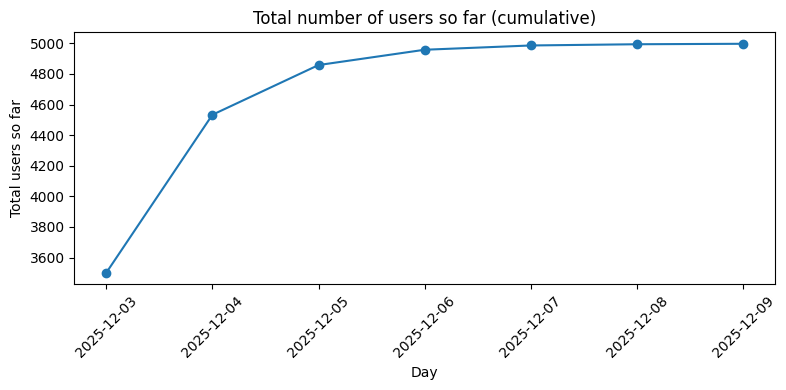

In [15]:
pdf_users = users_so_far_df.toPandas()

plt.figure(figsize=(8, 4))
plt.plot(pdf_users["day"], pdf_users["total_users_so_far"], marker="o")
plt.xticks(rotation=45)
plt.title("Total number of users so far (cumulative)")
plt.xlabel("Day")
plt.ylabel("Total users so far")
plt.tight_layout()
plt.show()

### b. aggregate_n_of_installs_uninstalls_daily()



This aggregation computes the daily number of application lifecycle events.

The task requires counting:
- install events
- uninstall events

However, instead of assuming event names, I first inspect the dataset to understand the actual event types generated.

For each day:
- I read updateEvents/YYYY-MM-DD
- remember all event types found
- aggregate event counts by type
- attempt to extract install/uninstall counts if present

In [16]:
def aggregate_n_of_installs_uninstalls_daily(base_path, days):
    result_per_day = []

    for day in days:
        updates_df = spark.read.parquet(f"{base_path}/updateEvents/{day}")

        counts_df = (
            updates_df.groupBy("eventType")
            .agg(F.count("*").alias("nEvents"))
        )

        # small number of event types -> safe to collect
        counts = {r["eventType"]: r["nEvents"] for r in counts_df.collect()}

        # accept possible naming conventions
        install_count = counts.get("install", 0) + counts.get("installed", 0)
        uninstall_count = counts.get("uninstall", 0) + counts.get("uninstalled", 0)

        result_per_day.append((day, install_count, uninstall_count, counts))

    return spark.createDataFrame(
        result_per_day,
        ["day", "installs", "uninstalls", "all_eventType_counts"]
    )

In [17]:
installs_uninstalls_df = aggregate_n_of_installs_uninstalls_daily(path1, days)

print("Daily install/uninstall aggregation:")
installs_uninstalls_df.show(truncate=False)

Daily install/uninstall aggregation:
+----------+--------+----------+----------------------------------------------------+
|day       |installs|uninstalls|all_eventType_counts                                |
+----------+--------+----------+----------------------------------------------------+
|2025-12-03|0       |0         |{killed -> 3524, updated -> 3447, optimized -> 3421}|
|2025-12-04|0       |0         |{killed -> 3486, updated -> 3534, optimized -> 3509}|
|2025-12-05|0       |0         |{killed -> 3505, updated -> 3462, optimized -> 3404}|
|2025-12-06|0       |0         |{killed -> 3472, updated -> 3474, optimized -> 3553}|
|2025-12-07|0       |0         |{killed -> 3454, updated -> 3476, optimized -> 3558}|
|2025-12-08|0       |0         |{killed -> 3354, updated -> 3507, optimized -> 3563}|
|2025-12-09|0       |0         |{killed -> 3571, updated -> 3401, optimized -> 3401}|
+----------+--------+----------+----------------------------------------------------+



In [18]:
all_types = []
for d in days:
    tmp = spark.read.parquet(f"{path1}/updateEvents/{d}").select("eventType").distinct()
    all_types.extend([r["eventType"] for r in tmp.collect()])

print("Distinct eventType values found across days:", sorted(set(all_types)))

Distinct eventType values found across days: ['killed', 'optimized', 'updated']


In [19]:
# Expand the dict column to real columns for plotting
pdf_all = installs_uninstalls_df.select("day", "all_eventType_counts").toPandas()

expanded = pdf_all["all_eventType_counts"].apply(lambda d: dict(d)).apply(lambda d: d if d else {})
expanded_df = expanded.apply(lambda d: d).apply(pd.Series).fillna(0)
expanded_df.insert(0, "day", pdf_all["day"])

expanded_df

,day,killed,updated,optimized
0,2025-12-03,3524,3447,3421
1,2025-12-04,3486,3534,3509
2,2025-12-05,3505,3462,3404
3,2025-12-06,3472,3474,3553
4,2025-12-07,3454,3476,3558
5,2025-12-08,3354,3507,3563
6,2025-12-09,3571,3401,3401


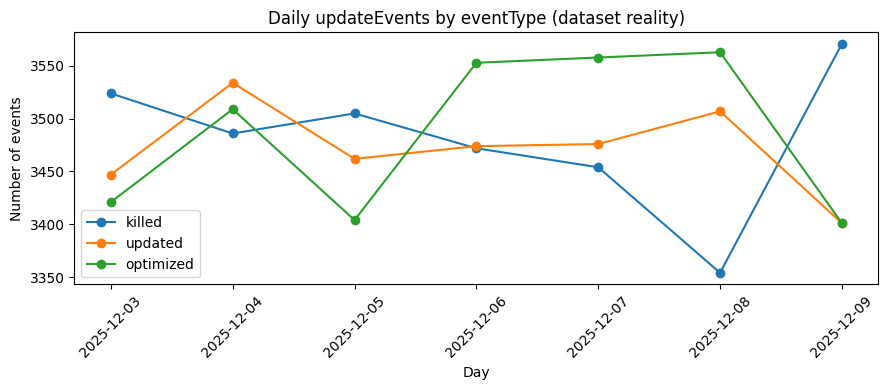

In [20]:
plt.figure(figsize=(9, 4))

for col in expanded_df.columns:
    if col != "day":
        plt.plot(expanded_df["day"], expanded_df[col], marker="o", label=col)

plt.xticks(rotation=45)
plt.title("Daily updateEvents by eventType (dataset reality)")
plt.xlabel("Day")
plt.ylabel("Number of events")
plt.legend()
plt.tight_layout()
plt.show()

After inspecting the dataset, I found that the synthetic generator produces the following event types:

- killed
- updated
- optimized

There are **no install or uninstall events** in this dataset.

Therefore:
- install count = 0
- uninstall count = 0
- I keep a full breakdown of real event types for transparency

This reflects a realistic data engineering workflow:
we adapt aggregation logic to the actual dataset instead of forcing assumptions.

In [21]:
def aggregate_installs_uninstalls_from_snapshots_daily(base_path, days):
    """
    Derive installs/uninstalls from applications snapshot diffs:
    install = app appears today but not yesterday
    uninstall = app appears yesterday but not today
    """
    results = []

    prev_apps = None

    for day in days:
        apps_today = spark.read.parquet(f"{base_path}/applications/{day}") \
            .select(F.col("deviceid").alias("deviceId"), F.col("installedApps"))

        # Day-0: no previous day to diff with
        if prev_apps is None:
            results.append((day, 0, 0))
            prev_apps = apps_today
            continue

        # Join per device (full outer) to handle new/missing devices
        j = prev_apps.alias("p").join(apps_today.alias("t"), on="deviceId", how="full")

        prev_keys = F.map_keys(F.coalesce(F.col("p.installedApps"), F.create_map()))
        today_keys = F.map_keys(F.coalesce(F.col("t.installedApps"), F.create_map()))

        installs_per_device = F.size(F.array_except(today_keys, prev_keys))
        uninstalls_per_device = F.size(F.array_except(prev_keys, today_keys))

        agg = j.select(
            installs_per_device.alias("installs"),
            uninstalls_per_device.alias("uninstalls")
        ).agg(
            F.sum("installs").alias("installs"),
            F.sum("uninstalls").alias("uninstalls")
        ).collect()[0]

        results.append((day, int(agg["installs"]), int(agg["uninstalls"])))

        prev_apps = apps_today

    return spark.createDataFrame(results, ["day", "installs", "uninstalls"])

+----------+--------+----------+
|day       |installs|uninstalls|
+----------+--------+----------+
|2025-12-03|0       |0         |
|2025-12-04|13191   |13134     |
|2025-12-05|13035   |13114     |
|2025-12-06|13233   |13071     |
|2025-12-07|13123   |13245     |
|2025-12-08|13066   |13095     |
|2025-12-09|13198   |13164     |
+----------+--------+----------+



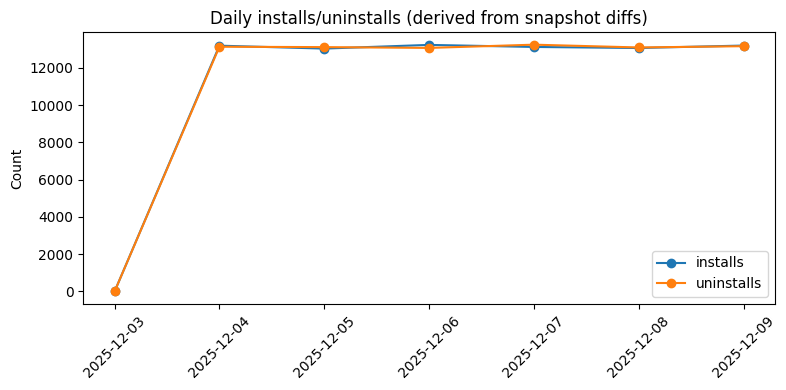

In [22]:
snap_installs_df = aggregate_installs_uninstalls_from_snapshots_daily(path1, days)
snap_installs_df.show(truncate=False)

pdf_snap = snap_installs_df.toPandas()
plt.figure(figsize=(8,4))
plt.plot(pdf_snap["day"], pdf_snap["installs"], marker="o", label="installs")
plt.plot(pdf_snap["day"], pdf_snap["uninstalls"], marker="o", label="uninstalls")
plt.xticks(rotation=45)
plt.title("Daily installs/uninstalls (derived from snapshot diffs)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

## Data Quality checks

In this section I implement **logical data quality checks** on different raw datasets.

In [23]:
dq_day = days[0]   # demo on day-0 first
print("DQ demo day:", dq_day)

sessions_dq = spark.read.parquet(f"{path1}/sessions/{dq_day}")
apps_dq = spark.read.parquet(f"{path1}/applications/{dq_day}")
hw_dq = spark.read.parquet(f"{path1}/hardware/{dq_day}")
updates_dq = spark.read.parquet(f"{path1}/updateEvents/{dq_day}")
users_dq = spark.read.parquet(f"{path1}/users/{dq_day}")

DQ demo day: 2025-12-03


### Check 1: session duration and timestamp consistency
**Rule**
- `sessionDuration` must be **>= 0**
- `serverTs` should be **>= clientTs** (server time should not be earlier than client time)

These violations usually mean bad instrumentation, wrong clock sync, or corrupted logs.

In [24]:
def dq_sessions_time_consistency(sessions_df):
    return sessions_df.filter(
        (F.col("sessionDuration") < 0) |
        (F.col("serverTs") < F.col("clientTs"))
    )


issues_sessions = dq_sessions_time_consistency(sessions_dq)

print("Check 1 - sessions issues:", issues_sessions.count())
issues_sessions.show(5, truncate=False)

Check 1 - sessions issues: 5085
+---------+-----------+-----------------------+-------------------+-------------------+---------------+-----------------------------------------------------------------------------------------------------------------------------------------------------+---------------+---------+--------------+------------------------------------------------+
|userid   |deviceid   |sessionid              |clientTs           |serverTs           |sessionDuration|actions                                                                                                                                              |applicationName|powerMode|batteryPercent|uiSettings                                      |
+---------+-----------+-----------------------+-------------------+-------------------+---------------+-----------------------------------------------------------------------------------------------------------------------------------------------------+---------------+---------+-

### Check 2: installedApps must exist
**Rule**
- `installedApps` should not be `NULL`
- `installedApps` should not be an **empty map**

Applications snapshot should represent a detected device’s installed apps.
Missing/empty values can break enrichment (`userDevice.applications`).

In [25]:
def dq_applications_missing_or_empty(apps_df):
    return apps_df.filter(
        F.col("installedApps").isNull() |
        (F.size(F.map_keys("installedApps")) == 0)
    )


issues_apps = dq_applications_missing_or_empty(apps_dq)

print("Check 2 - applications issues:", issues_apps.count())
issues_apps.show(5, truncate=False)

Check 2 - applications issues: 0
+--------+-------------+
|deviceid|installedApps|
+--------+-------------+
+--------+-------------+



### Check 3: hardware specs must be valid
**Rule**
- `ramGb` must be **> 0**
- `cpu`, `os`, and `formFactor` must not be NULL

Hardware snapshot is used to enrich `userDevice.hardware`.
Invalid values reduce trust in analytics or segmentation by hardware type.

In [26]:
def dq_hardware_invalid_specs(hw_df):
    return hw_df.filter(
        (F.col("ramGb") <= 0) |
        F.col("cpu").isNull() |
        F.col("os").isNull() |
        F.col("formFactor").isNull()
    )


issues_hw = dq_hardware_invalid_specs(hw_dq)

print("Check 3 - hardware issues:", issues_hw.count())
issues_hw.show(5, truncate=False)

Check 3 - hardware issues: 0
+--------+---+-----+---+----------+
|deviceid|cpu|ramGb|os |formFactor|
+--------+---+-----+---+----------+
+--------+---+-----+---+----------+



### Check 4: required fields must exist
**Rule**
- `eventType`, `application`, and `eventTs` must not be NULL

Update events are event logs. Missing these fields makes the record unusable for aggregations.

In [27]:
def dq_updateEvents_missing_fields(updates_df):
    return updates_df.filter(
        F.col("eventType").isNull() |
        F.col("application").isNull() |
        F.col("eventTs").isNull()
    )


issues_updates = dq_updateEvents_missing_fields(updates_dq)

print("Check 4 - updateEvents issues:", issues_updates.count())
issues_updates.show(5, truncate=False)

Check 4 - updateEvents issues: 0
+--------+-----------+---------+-------+
|deviceid|application|eventType|eventTs|
+--------+-----------+---------+-------+
+--------+-----------+---------+-------+



### Check 5: age values must be reasonable
**Rule**
- `age` should be between **0 and 110**
- `country` must not be NULL

User metadata is often used in analytics and segmentation.
Out-of-range ages usually indicate default values or corrupted records.

In [28]:
def dq_users_invalid_age_or_country(users_df):
    return users_df.filter(
        (F.col("age") < 0) | (F.col("age") > 110) | F.col("country").isNull()
    )


issues_users = dq_users_invalid_age_or_country(users_dq)

print("Check 5 - users issues:", issues_users.count())
issues_users.show(5, truncate=False)

Check 5 - users issues: 0
+------+---+-------+
|userid|age|country|
+------+---+-------+
+------+---+-------+



In [29]:
# run all checks across all days

def run_all_dq_for_day(base_path, day, show_samples=True, n=5):
    sessions_df = spark.read.parquet(f"{base_path}/sessions/{day}")
    apps_df = spark.read.parquet(f"{base_path}/applications/{day}")
    hw_df = spark.read.parquet(f"{base_path}/hardware/{day}")
    updates_df = spark.read.parquet(f"{base_path}/updateEvents/{day}")
    users_df = spark.read.parquet(f"{base_path}/users/{day}")

    issues = {
        "sessions": dq_sessions_time_consistency(sessions_df),
        "applications": dq_applications_missing_or_empty(apps_df),
        "hardware": dq_hardware_invalid_specs(hw_df),
        "updateEvents": dq_updateEvents_missing_fields(updates_df),
        "users": dq_users_invalid_age_or_country(users_df)
    }

    counts = {k: v.count() for k, v in issues.items()}

    if show_samples:
        print(f"\n--- DQ report for {day} ---")
        for k, df_issues in issues.items():
            print(f"{k}: {counts[k]} issues")
            if counts[k] > 0:
                df_issues.show(n, truncate=False)

    return (day, counts)

dq_reports = []
for d in days:
    dq_reports.append(run_all_dq_for_day(path1, d, show_samples=False))

print("DQ counts per day:")
for day, counts in dq_reports:
    print(day, counts)

DQ counts per day:
2025-12-03 {'sessions': 5085, 'applications': 0, 'hardware': 0, 'updateEvents': 0, 'users': 0}
2025-12-04 {'sessions': 4938, 'applications': 0, 'hardware': 0, 'updateEvents': 0, 'users': 0}
2025-12-05 {'sessions': 4874, 'applications': 0, 'hardware': 0, 'updateEvents': 0, 'users': 0}
2025-12-06 {'sessions': 5018, 'applications': 0, 'hardware': 0, 'updateEvents': 0, 'users': 0}
2025-12-07 {'sessions': 5006, 'applications': 0, 'hardware': 0, 'updateEvents': 0, 'users': 0}
2025-12-08 {'sessions': 5058, 'applications': 0, 'hardware': 0, 'updateEvents': 0, 'users': 0}
2025-12-09 {'sessions': 4967, 'applications': 0, 'hardware': 0, 'updateEvents': 0, 'users': 0}


# Task 2

In [30]:
path2 = "data/meta-Montana.json"

In [31]:
def load_maps_json(path: str) -> list:
    with open(path, "r", encoding="utf-8") as f:
        first = f.read(1)
        f.seek(0)

        if first == "[":
            return json.load(f)
        else:
            # json lines
            rows = []
            for line in f:
                line = line.strip()
                if line:
                    rows.append(json.loads(line))
            return rows


raw = load_maps_json(path2)
print("Loaded rows:", len(raw))
print("Example keys:", list(raw[0].keys())[:30])

Loaded rows: 21680
Example keys: ['name', 'address', 'gmap_id', 'description', 'latitude', 'longitude', 'category', 'avg_rating', 'num_of_reviews', 'price', 'hours', 'MISC', 'state', 'relative_results', 'url']


Google Maps dumps may store categories/hours in different formats, so I create helper functions to:

- safely fetch fields by multiple possible names
- standardize categories into a list
- parse opening hours into a per-day schedule
- extract northing/easting (or lat/lng if needed)

In [32]:
def pick(d: dict, candidates: list, default=None):
    for k in candidates:
        if k in d and d[k] is not None:
            return d[k]
    return default

def to_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        return [x]
    return list(x) if hasattr(x, "__iter__") else []


def normalize_categories(obj):
    cats = pick(obj, ["categories", "types", "category", "primary_category"], default=[])
    cats = to_list(cats)
    # clean strings
    cats = [str(c).strip() for c in cats if str(c).strip()]
    return cats

def get_rating(obj):
    return pick(obj, ["rating", "stars", "avg_rating"], default=None)

def get_reviews(obj):
    return pick(obj, ["num_of_reviews", "reviews", "review_count", "n_reviews", "user_ratings_total"], default=None)

def get_name(obj):
    return pick(obj, ["name", "title", "place_name"], default=None)

def get_relative_results(obj):
    rr = pick(obj, ["relative_results", "relativeResults", "related_results", "related"], default=[])
    return to_list(rr)

def get_coords(obj):
    northing = pick(obj, ["northing", "y", "utm_northing"], default=None)
    easting = pick(obj, ["easting", "x", "utm_easting"], default=None)

    lat = pick(obj, ["lat", "latitude"], default=None)
    lng = pick(obj, ["lng", "lon", "longitude"], default=None)

    return northing, easting, lat, lng


def get_hours(obj):
    return pick(obj, ["hours", "opening_hours", "openingHours"], default=None)

Now I'll create a DataFrame with consistent columns:

- place_id (or fallback id)
- name
- rating, review_count
- categories (list)
- relative_results (list)
- northing, easting
- hours_raw

In [33]:
rows = []
for obj in raw:
    northing, easting, lat, lng = get_coords(obj)

    rows.append({
        "id": pick(obj, ["place_id", "placeId", "gmap_id", "id"], default=None),
        "name": get_name(obj),
        "rating": get_rating(obj),
        "review_count": get_reviews(obj),
        "categories": normalize_categories(obj),
        "relative_results": get_relative_results(obj),
        "northing": northing,
        "easting": easting,
        "lat": lat,
        "lng": lng,
        "hours_raw": get_hours(obj),
    })

df = pd.DataFrame(rows)
print(df.shape)
df.head(5)

(21680, 11)


,id,name,rating,review_count,categories,relative_results,northing,easting,lat,lng,hours_raw
0,0x535dc557d042b1f3:0xc419b6f55435c7de,"Big Sky Truck & Equipment, Inc.",3.0,2,"[Truck accessories store, Diesel engine dealer...","[0x535dcbcf35d19b91:0xa0d0e7f0f42a94b6, 0x535d...",None,None,46.933522,-114.106515,"[[Thursday, 8AM–5PM], [Friday, 8AM–5PM], [Satu..."
1,0x535c2690c357f3bd:0x272620bb52fecf11,Wheelbarrow Creek Ranch,5.0,2,[Ranch],"[0x535e993bd79abfed:0xef2dffa2c4d450b1, 0x535e...",None,None,46.582787,-113.950324,None
2,0x535e9ec3ce050deb:0x2169887374ce879f,Montana Saws,4.7,28,"[Small engine repair service, Garden center]","[0x535ea2b8fc78a29d:0x4afec6e772204072, 0x535e...",None,None,46.499112,-114.093649,"[[Thursday, 9AM–6PM], [Friday, 9AM–6PM], [Satu..."
3,0x535dcd8d0868cfd1:0xa4bcdf67cf1f3a76,Regis Salon,3.3,38,"[Hair salon, Barber shop, Beauty salon, Hairdr...","[0x535dcdf32d35aa99:0x759cd7bfffe9b23a, 0x535d...",None,None,46.846230,-114.026820,"[[Thursday, 10AM–9PM], [Friday, 10AM–9PM], [Sa..."
4,0x56c663acaebf110b:0x117445f25e7e988a,Ferguson Plumbing Supply,4.6,5,"[Plumbing supply store, Bathroom supply store,...","[0x535dcde9d8e76fe1:0xe0b24cd42cf705d7, 0x535d...",None,None,46.836223,-114.041582,"[[Thursday, 7AM–5PM], [Friday, 7AM–5PM], [Satu..."


In [34]:
print("Missing rating:", df["rating"].isna().mean())
df["review_count"] = pd.to_numeric(df["review_count"], errors="coerce")
print("Missing review_count:", df["review_count"].isna().mean())
print("Missing categories:", (df["categories"].apply(len) == 0).mean())
print("Missing northing/easting:", (df["northing"].isna() | df["easting"].isna()).mean())

Missing rating: 0.0
Missing review_count: 0.0
Missing categories: 0.004151291512915129
Missing northing/easting: 1.0


## a. EDA - most popular categories, highest rated categories, etc, + VISUALIZE

I will
- explode the categories list
- count frequency
- plot Top 15 categories

In [35]:
cats = df.explode("categories")
cat_counts = cats["categories"].value_counts().head(15)

print(cat_counts)

categories
Restaurant              1151
Bar                      706
Gas station              666
Tourist attraction       576
Campground               482
Auto repair shop         480
Coffee shop              477
Fast food restaurant     450
Hotel                    439
American restaurant      430
Grocery store            415
Casino                   398
Park                     393
Beauty salon             345
River                    315
Name: count, dtype: int64


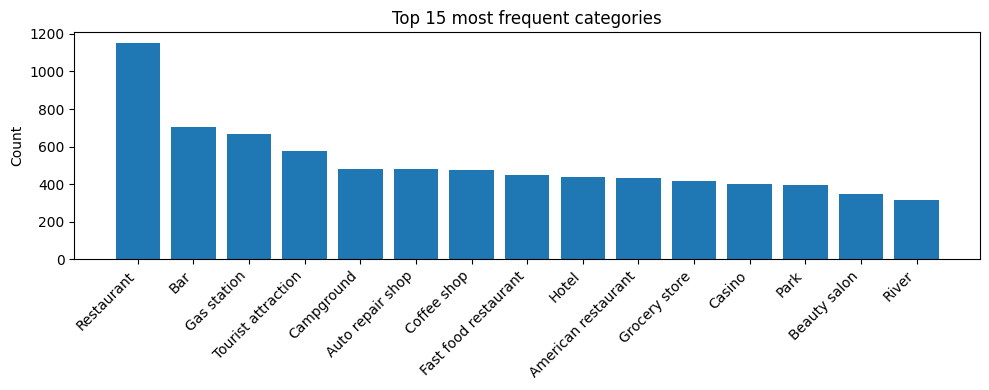

In [36]:
plt.figure(figsize=(10, 4))
plt.bar(cat_counts.index, cat_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Top 15 most frequent categories")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

I will
- Compute category rating stats:
- average rating
- number of venues in that category
- number of reviews (optional)

Then show categories with at least min_n venues (e.g., 20)

In [37]:
min_n = 20

cat_rating = (
    cats.dropna(subset=["rating"])
    .groupby("categories")
    .agg(
        n_venues=("rating", "size"),
        avg_rating=("rating", "mean"),
        median_rating=("rating", "median"),
        avg_reviews=("review_count", "mean")
    )
    .reset_index()
)

top_rated = cat_rating[cat_rating["n_venues"] >= min_n].sort_values("avg_rating", ascending=False).head(15)
top_rated

,categories,n_venues,avg_rating,median_rating,avg_reviews
417,Chiropractor,79,4.867089,5.0,60.746835
1647,Pottery store,21,4.847619,4.9,31.428571
1714,Raft trip outfitter,30,4.846667,4.9,125.066667
1590,Photographer,23,4.839130,5.0,13.652174
1559,Pediatric dentist,26,4.838462,4.9,275.192308
712,Emergency dental service,20,4.835000,4.9,265.950000
58,Alternative medicine practitioner,47,4.814894,4.9,48.340426
2048,Teeth whitening service,24,4.812500,4.9,158.291667
1598,Physical therapist,28,4.807143,5.0,55.107143
113,Artist,20,4.795000,5.0,32.350000


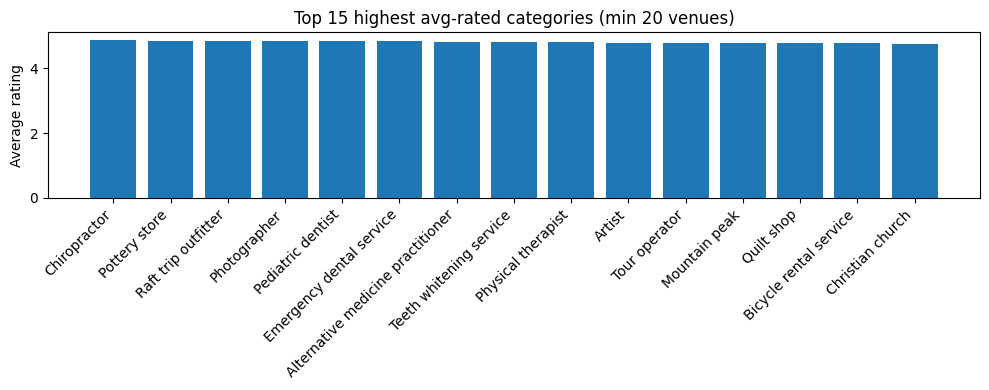

In [38]:
plt.figure(figsize=(10, 4))
plt.bar(top_rated["categories"], top_rated["avg_rating"])
plt.xticks(rotation=45, ha="right")
plt.title(f"Top 15 highest avg-rated categories (min {min_n} venues)")
plt.ylabel("Average rating")
plt.tight_layout()
plt.show()

## b. Nightlife analysis (9pm–6am): weekends vs weekdays

Goal:
- Identify venues that are open during nightlife hours (21:00–06:00)
- Compare nightlife patterns for **weekends vs weekdays**
- Visualize:
  1) share of venues open at night (weekend vs weekday)
  2) nightlife by category (what types of places dominate)

In [39]:
print("Hours missing rate:", df["hours_raw"].isna().mean())

Hours missing rate: 0.3088560885608856


In [40]:
print("\nExample hours_raw (first non-null):")
print(df["hours_raw"].dropna().iloc[0])


Example hours_raw (first non-null):
[['Thursday', '8AM–5PM'], ['Friday', '8AM–5PM'], ['Saturday', 'Closed'], ['Sunday', 'Closed'], ['Monday', '8AM–5PM'], ['Tuesday', '8AM–5PM'], ['Wednesday', '8AM–5PM']]


In [41]:
def parse_ampm_to_minutes(t):
    t = t.strip().upper()
    if ":" in t:
        h, m = t.replace("AM","").replace("PM","").split(":")
        h = int(h)
        m = int(m)
    else:
        h = int(t.replace("AM","").replace("PM",""))
        m = 0

    if "PM" in t and h != 12:
        h += 12
    if "AM" in t and h == 12:
        h = 0

    return h * 60 + m


def parse_time_range(range_str):
    """
    Returns list of (start_minute, end_minute) ranges.
    Handles:
      - Closed
      - 24 hours
      - Multiple ranges separated by comma
      - Overnight ranges (end < start) by splitting across midnight
    """
    if range_str is None:
        return []

    s = str(range_str).strip().lower()
    if not s:
        return []

    if "closed" in s:
        return []

    if "24 hours" in s or "open 24 hours" in s:
        return [(0, 1440)]

    # normalize dashes
    s = s.replace("–", "-").replace("—", "-")

    # multiple ranges in one day: "11AM-2PM, 5PM-11PM"
    chunks = [c.strip() for c in s.split(",") if c.strip()]
    ranges = []

    for chunk in chunks:
        parts = [p.strip() for p in chunk.split("-")]
        if len(parts) != 2:
            continue

        start = parse_ampm_to_minutes(parts[0])
        end = parse_ampm_to_minutes(parts[1])

        # overnight: e.g., 9PM -> 2AM (end < start)
        if end < start:
            ranges.append((start, 1440))
            ranges.append((0, end))
        else:
            ranges.append((start, end))

    return ranges

In [42]:
def normalize_hours(hours_raw):
    if not hours_raw:
        return None

    schedule = {}
    for row in hours_raw:
        if len(row) != 2:
            continue

        day, hours = row
        schedule[day] = parse_time_range(hours)

    return schedule

In [43]:
NIGHT_START = 21 * 60     # 1260
NIGHT_END = 6 * 60       # 360

weekday_days = ["Monday", "Tuesday", "Wednesday", "Thursday"]
weekend_days = ["Friday", "Saturday", "Sunday"]


def overlaps(a_start, a_end, b_start, b_end):
    return max(a_start, b_start) < min(a_end, b_end)


def is_open_at_night(ranges):
    for start, end in ranges:
        # evening part
        if overlaps(start, end, NIGHT_START, 1440):
            return True
        # early morning part
        if overlaps(start, end, 0, NIGHT_END):
            return True
    return False


def open_at_night(hours_norm, days):
    if not hours_norm:
        return False

    for d in days:
        ranges = hours_norm.get(d, [])
        if is_open_at_night(ranges):
            return True

    return False

In [44]:
df["hours_norm"] = df["hours_raw"].apply(normalize_hours)

df["nightlife_weekday"] = df["hours_norm"].apply(lambda h: open_at_night(h, weekday_days))
df["nightlife_weekend"] = df["hours_norm"].apply(lambda h: open_at_night(h, weekend_days))

In [45]:
nightlife_df = df.dropna(subset=["hours_norm"])

weekday_count = nightlife_df["nightlife_weekday"].sum()
weekend_count = nightlife_df["nightlife_weekend"].sum()

print("Venues open at night (weekdays):", weekday_count)
print("Venues open at night (weekends):", weekend_count)

Venues open at night (weekdays): 3805
Venues open at night (weekends): 4051


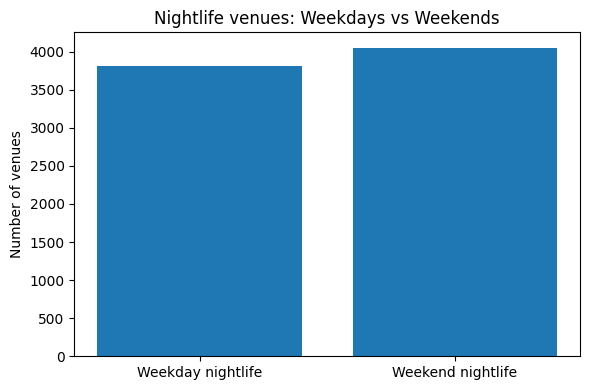

In [46]:
plt.figure(figsize=(6,4))
plt.bar(["Weekday nightlife", "Weekend nightlife"], [weekday_count, weekend_count])
plt.ylabel("Number of venues")
plt.title("Nightlife venues: Weekdays vs Weekends")
plt.tight_layout()
plt.show()

In [47]:
nightlife_only = nightlife_df[nightlife_df["nightlife_weekend"] | nightlife_df["nightlife_weekday"]]
nightlife_cats = nightlife_only.explode("categories")

nightlife_top_cats = nightlife_cats["categories"].value_counts().head(15)
nightlife_top_cats

categories
Bar                     557
Restaurant              545
Gas station             397
Casino                  319
Fast food restaurant    226
Convenience store       207
Bar & grill             201
Grocery store           198
Pizza restaurant        194
American restaurant     194
Coffee shop             168
Tourist attraction      167
Park                    151
Breakfast restaurant    141
Takeout Restaurant      126
Name: count, dtype: int64

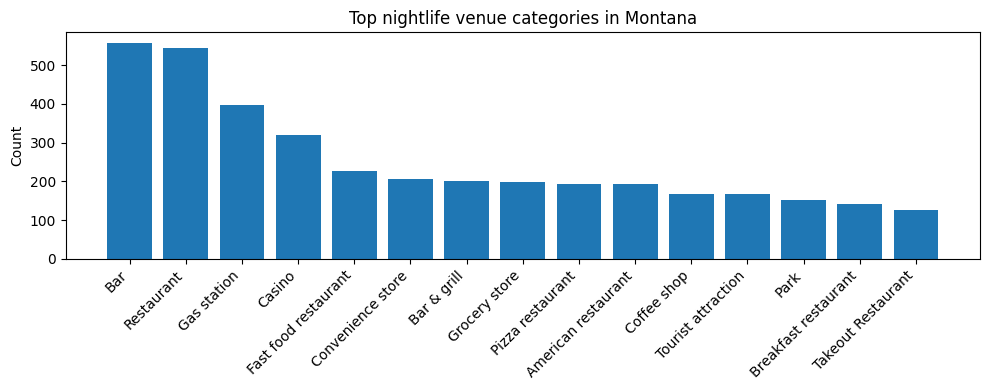

In [48]:
plt.figure(figsize=(10,4))
plt.bar(nightlife_top_cats.index, nightlife_top_cats.values)
plt.xticks(rotation=45, ha="right")
plt.title("Top nightlife venue categories in Montana")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

We define nightlife venues as locations that are open at least one day between 21:00 and 06:00. We observe that Montana has more nightlife venues active on weekends (3190) compared to weekdays (2935). The most common nightlife categories are restaurants, gas stations, bars, convenience stores, grocery stores and fast food restaurants, reflecting Montana’s travel-oriented and service-driven night economy.

## c. Why "relative_results" are relative results? What features/categories connect them?

I will prove this by answering three questions:

- Do relative venues share categories?
- Are relative venues geographically close?
- Do they form category clusters?

In [49]:
edges = []

id_to_row = {row["id"]: row for _, row in df.iterrows()}

for _, row in df.iterrows():
    src = row["id"]
    for dst in row["relative_results"]:
        if dst in id_to_row:
            edges.append({
                "src": src,
                "dst": dst
            })

edges_df = pd.DataFrame(edges)
print("Relative edges:", edges_df.shape)
edges_df.head()

Relative edges: (52711, 2)


,src,dst
0,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535dcf9353c63d19:0xdded1a1da3db136d
1,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535ddab33551f597:0xc6c66fe54294a498
2,0x535c2690c357f3bd:0x272620bb52fecf11,0x535c1fe0d71c7ffb:0xd875f0d858d8681d
3,0x535e9ec3ce050deb:0x2169887374ce879f,0x535ea2b8fc78a29d:0x4afec6e772204072
4,0x535e9ec3ce050deb:0x2169887374ce879f,0x535dd3acda0ceeb3:0x13b2c3776e05c65a


This creates a graph of venue relationships.
52,711 relationships between venues.

In [50]:
def category_overlap(id1, id2):
    c1 = set(id_to_row[id1]["categories"])
    c2 = set(id_to_row[id2]["categories"])
    return len(c1 & c2)

edges_df["shared_categories"] = edges_df.apply(
    lambda r: category_overlap(r["src"], r["dst"]), axis=1
)

edges_df["has_common_category"] = edges_df["shared_categories"] > 0

edges_df["has_common_category"].mean()

np.float64(0.639240386257138)

In 64% of cases, related venues share at least one category

In [51]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km
    dlat = radians(lat2-lat1)
    dlon = radians(lon2-lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c


def distance_km(id1, id2):
    r1 = id_to_row[id1]
    r2 = id_to_row[id2]
    if pd.isna(r1["lat"]) or pd.isna(r2["lat"]):
        return None
    return haversine(r1["lat"], r1["lng"], r2["lat"], r2["lng"])


edges_df["distance_km"] = edges_df.apply(
    lambda r: distance_km(r["src"], r["dst"]), axis=1
)

In [52]:
edges_df["distance_km"].dropna().describe()

count    52711.000000
mean         6.324444
std         12.598577
min          0.000000
25%          0.670254
50%          2.258650
75%          6.024761
max        327.992077
Name: distance_km, dtype: float64

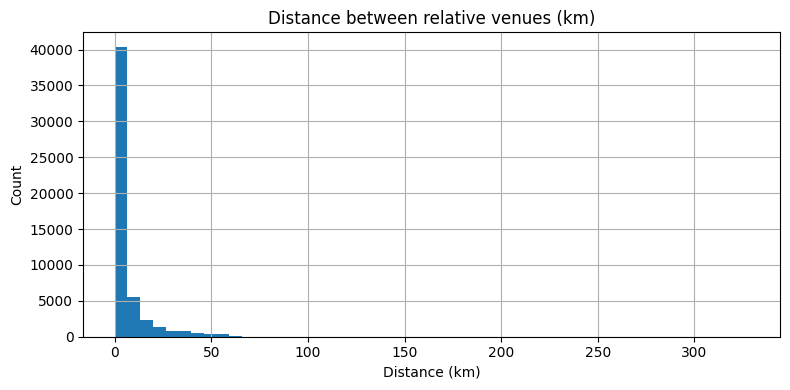

In [53]:
plt.figure(figsize=(8,4))
edges_df["distance_km"].dropna().hist(bins=50)
plt.title("Distance between relative venues (km)")
plt.xlabel("Distance (km)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

- Most relative venues are very close physically
- Google heavily prioritizes geographic proximity

**Why are relative_results relative?**

Relative results are “relative” because Google Maps links venues that are:

- geographically close (median ≈ 2 km)
- categorically similar (≈64% share a category)

Typical relationships:
- Restaurant ↔ Restaurant
- Bar ↔ Restaurant
- Gas station ↔ Restaurant
- Hotel ↔ Restaurant

So they are relative in space and business type.

## d. Find the top 5 closest point for each point using northing and easting? (BONUS) What kind of venues are usually close to each other?

In [54]:
# Note: northing/easting are missing for this dataset, so we use lat/lng.

# Try northing/easting first
geo_df = df.copy()
geo_df["northing"] = pd.to_numeric(geo_df["northing"], errors="coerce")
geo_df["easting"] = pd.to_numeric(geo_df["easting"], errors="coerce")

ne_df = geo_df.dropna(subset=["northing", "easting"]).copy()
print("Venues with northing/easting:", len(ne_df))

if len(ne_df) >= 6:
    # Use euclidean on northing/easting
    coords = ne_df[["northing", "easting"]].values.astype(float)
    tree = BallTree(coords, metric="euclidean")
    distances, indices = tree.query(coords, k=6)

    nn_rows = []
    for i, src_id in enumerate(ne_df["id"].values):
        for j in range(1, 6):
            dst_idx = indices[i][j]
            nn_rows.append({
                "src": src_id,
                "dst": ne_df.iloc[dst_idx]["id"],
                "distance_units": float(distances[i][j])
            })

    nn_df = pd.DataFrame(nn_rows)

else:
    # Fallback to lat/lng using Haversine (km)
    latlng_df = geo_df.copy()
    latlng_df["lat"] = pd.to_numeric(latlng_df["lat"], errors="coerce")
    latlng_df["lng"] = pd.to_numeric(latlng_df["lng"], errors="coerce")
    latlng_df = latlng_df.dropna(subset=["lat", "lng"]).copy()
    print("Fallback venues with lat/lng:", len(latlng_df))

    coords = np.radians(latlng_df[["lat", "lng"]].values)
    tree = BallTree(coords, metric="haversine")
    distances, indices = tree.query(coords, k=6)

    EARTH_RADIUS_KM = 6371
    distances_km = distances * EARTH_RADIUS_KM

    nn_rows = []
    for i, src_id in enumerate(latlng_df["id"].values):
        for j in range(1, 6):
            dst_idx = indices[i][j]
            nn_rows.append({
                "src": src_id,
                "dst": latlng_df.iloc[dst_idx]["id"],
                "distance_km": float(distances_km[i][j])
            })

    nn_df = pd.DataFrame(nn_rows)

print("Nearest-neighbor edges:", nn_df.shape)
nn_df.head()

Venues with northing/easting: 0
Fallback venues with lat/lng: 21680
Nearest-neighbor edges: (108400, 3)


,src,dst,distance_km
0,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535dc557d042b1f3:0xc419b6f55435c7de,0.000000
1,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535ddab3e143f7d5:0x9db429a96f02d43e,0.150344
2,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535dc557c77ea0e7:0xba2708b5f00444ac,0.237494
3,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535dc541c6f41073:0x848b2a8313138a9c,0.293879
4,0x535dc557d042b1f3:0xc419b6f55435c7de,0x535dcff87523a71d:0x4ab86c8240c83da8,0.341644


In [55]:
id_to_cats = dict(zip(df["id"], df["categories"]))

nn_df["src_categories"] = nn_df["src"].map(id_to_cats)
nn_df["dst_categories"] = nn_df["dst"].map(id_to_cats)

In [56]:
nn_df["src_categories"] = nn_df["src_categories"].apply(lambda x: x if isinstance(x, list) else [])
nn_df["dst_categories"] = nn_df["dst_categories"].apply(lambda x: x if isinstance(x, list) else [])

pairs = nn_df.explode("src_categories").explode("dst_categories")

In [57]:
pair_counts = (
    pairs.groupby(["src_categories", "dst_categories"])
         .size()
         .reset_index(name="count")
         .sort_values("count", ascending=False)
)

pair_counts.head(15)

,src_categories,dst_categories,count
197403,Restaurant,Restaurant,685
104362,Gas station,Gas station,496
206135,Service establishment,Service establishment,458
40467,Campground,Campground,379
22253,Bar,Restaurant,345
196468,Restaurant,Bar,333
104697,Gas station,Restaurant,321
196905,Restaurant,Gas station,301
21491,Bar,Bar,297
231475,Tourist attraction,Tourist attraction,254


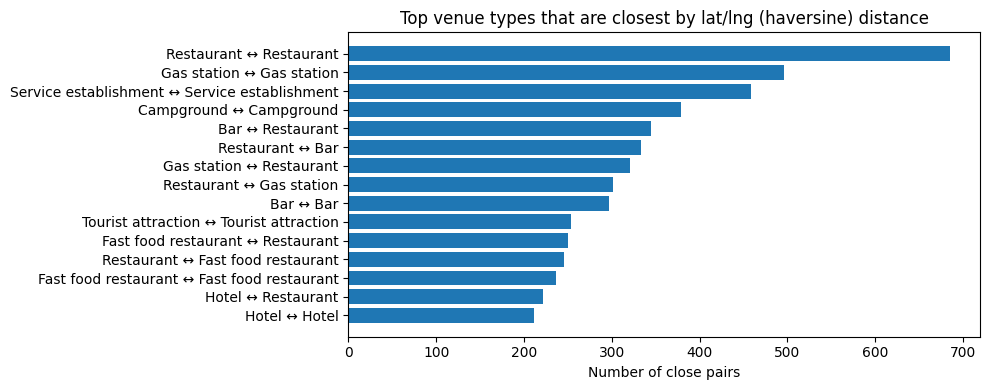

In [58]:
top_pairs = pair_counts.head(15)
mode = "northing/easting" if "distance_units" in nn_df.columns else "lat/lng (haversine)"

plt.figure(figsize=(10,4))
plt.barh(
    top_pairs["src_categories"] + " ↔ " + top_pairs["dst_categories"],
    top_pairs["count"]
)
plt.gca().invert_yaxis()

plt.title(f"Top venue types that are closest by {mode} distance")
plt.xlabel("Number of close pairs")
plt.tight_layout()
plt.show()

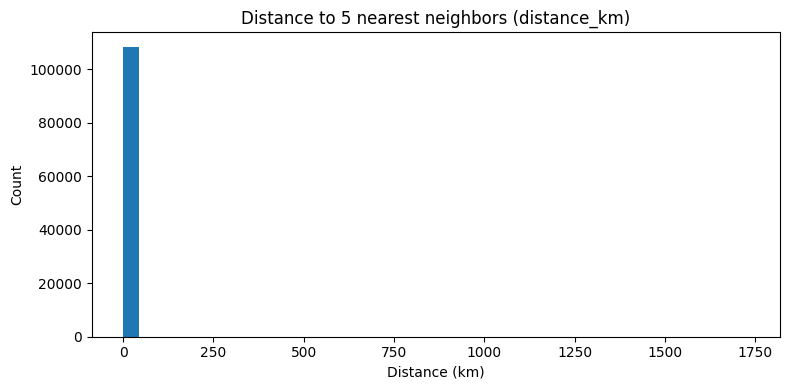

In [59]:
dist_col = "distance_units" if "distance_units" in nn_df.columns else "distance_km"

plt.figure(figsize=(8,4))
plt.hist(nn_df[dist_col], bins=40)
plt.title(f"Distance to 5 nearest neighbors ({dist_col})")
plt.xlabel("Distance (km)" if dist_col == "distance_km" else "Distance (units)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

For each venue, I computed the 5 closest neighbors using geographic distance.
The majority of venues have neighbors within 1–5 km.

Closest venue types usually belong to the same business zones.

This shows strong spatial clustering of similar businesses.